In [6]:
import numpy as np
import matplotlib.pyplot as plt
import mdtraj as md
from pathlib import Path

In [7]:
# Load trajectory
OUTPUT_DIR = Path('../test08/output')
TRAJ_PATH = Path('../../data/traj_skip100NoH.xtc')
TOP_PATH = Path('../../data/2JOF-0-proteinNoH.pdb')

pdb = md.load(str(TOP_PATH))
traj = md.load(str(TRAJ_PATH), top=pdb)
cvs = np.load(OUTPUT_DIR / 'latents.npy')

cv1, cv2 = cvs[:,0], cvs[:,1]

# Add path for pkgs to use robust alignment
import sys
from pathlib import Path
sys.path.append(str(Path('../../').resolve()))
from pkgs.utils import compute_aligned_phi_psi

phi, psi, residue_ids, _ = compute_aligned_phi_psi(traj)
print(f"Aligned residues: {residue_ids}")

Aligned residues: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]


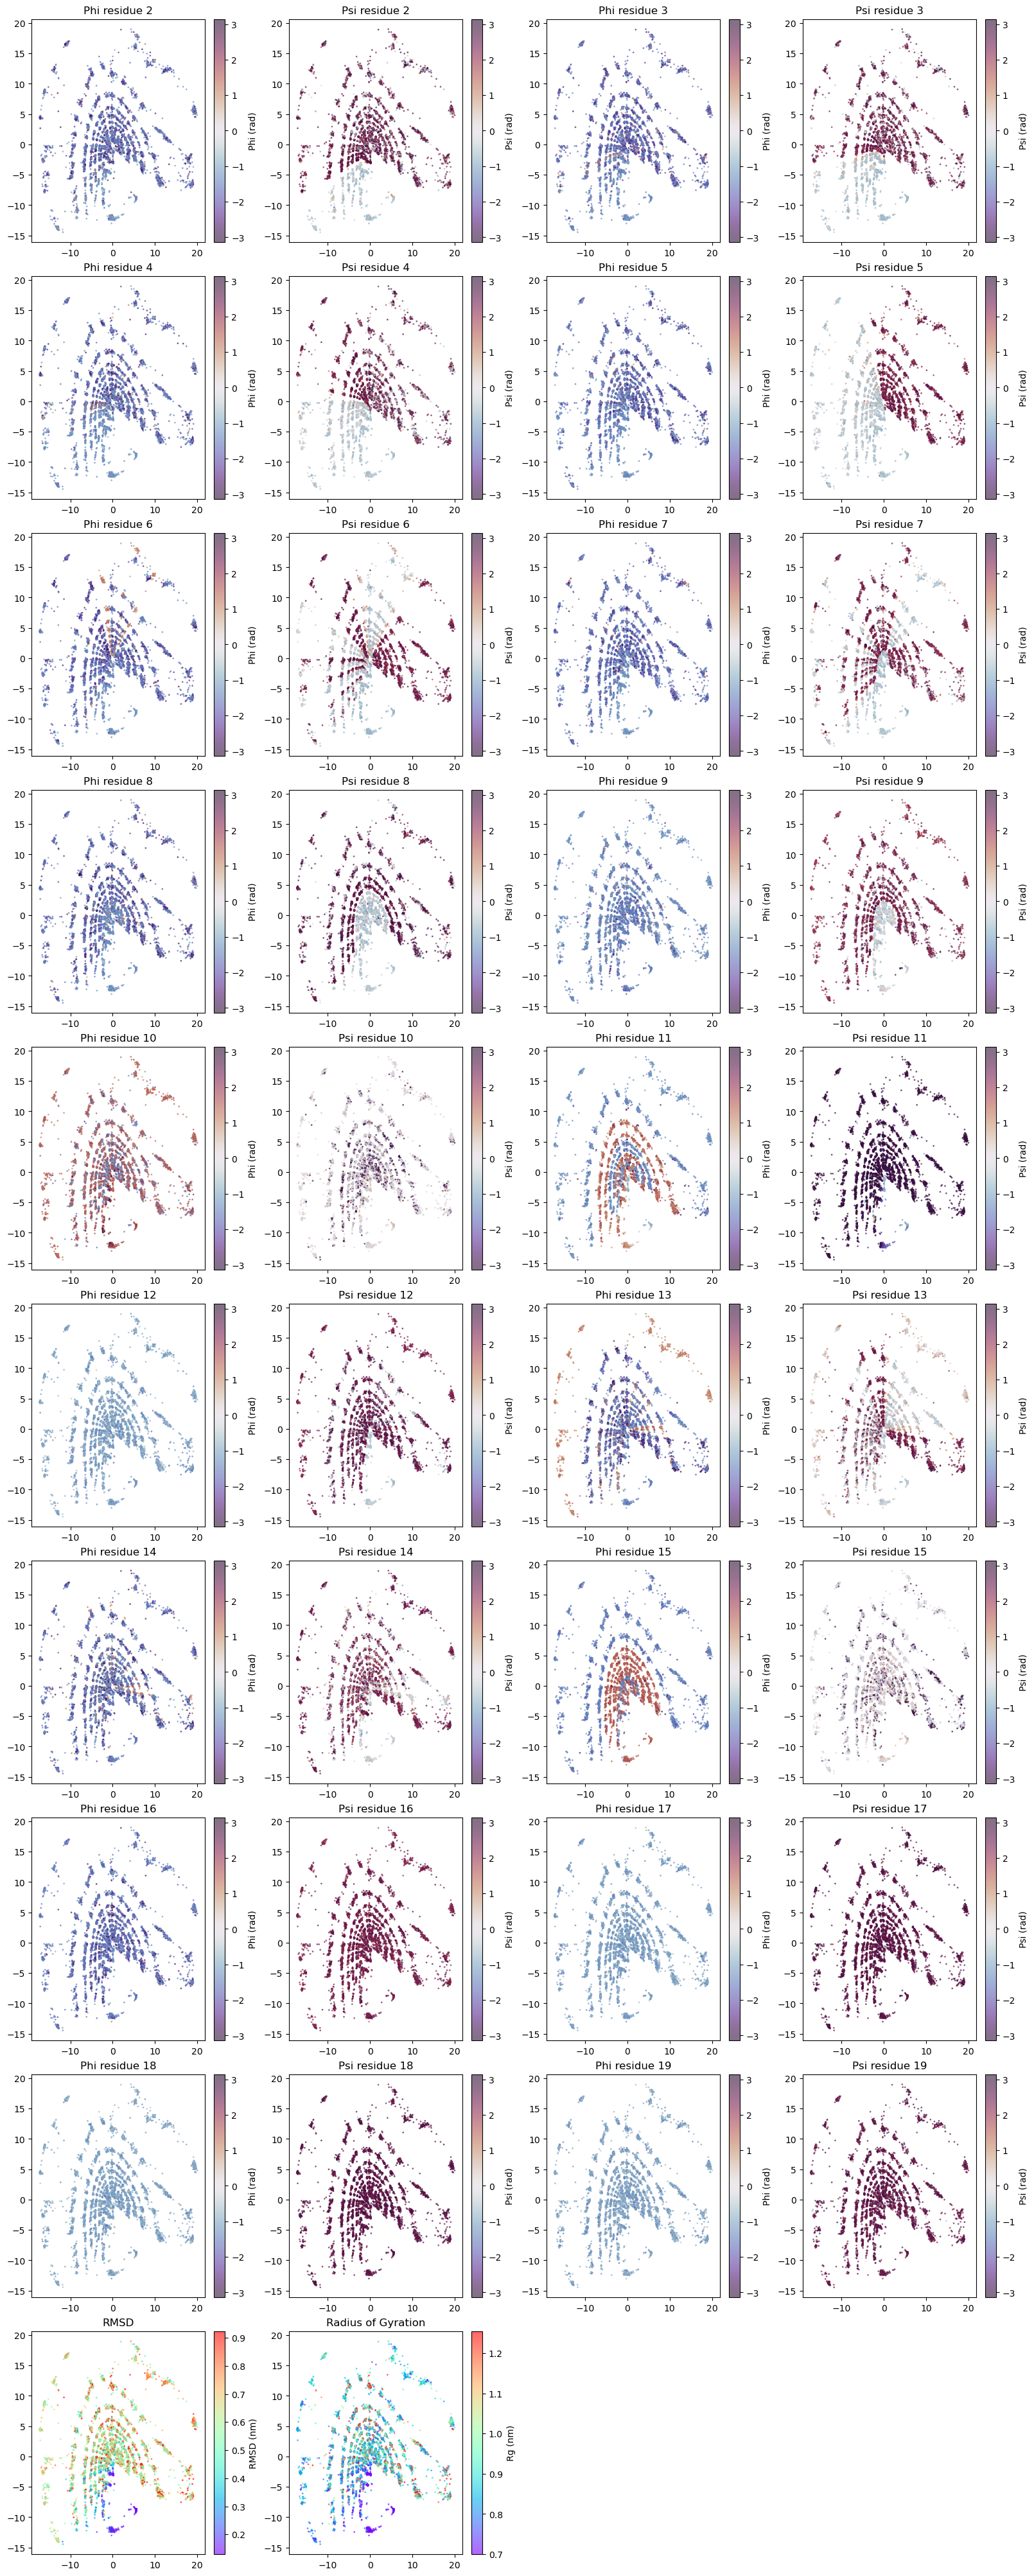

In [8]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Reset completo (evita che restino stili "dark" attivi)
mpl.rcdefaults()
plt.style.use("default")

# Forza background bianco + testi neri
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
})

# --- Calcoli ---
# (Already computed above using robust alignment)
# RMSD: use backbone-only + fit to reference
bb_idx = traj.topology.select("backbone")
rmsd = md.rmsd(traj, pdb, 0, atom_indices=bb_idx)
rg   = md.compute_rg(traj)

cv1 = cvs[:, 0]
cv2 = cvs[:, 1]

# robust color scale to avoid rare states being washed out
rmsd_vmin, rmsd_vmax = np.percentile(rmsd, [5, 95])
rg_vmin, rg_vmax = np.percentile(rg, [5, 95])

# Focus on Top residues from MI analysis if needed, 
# but for now let's just fix the plotting logic to show BOTH phi and psi
# and use the correct residue IDs.

n_res = len(residue_ids)

# --- Layout subplot ---
# Plotting both Phi and Psi for each residue
n_plots = n_res * 2 + 2
n_cols = 4
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(16, 4 * n_rows),
    constrained_layout=True
)

axes = np.array(axes).ravel()

# --- Plot phi and psi ---
plot_idx = 0
for i in range(n_res):
    res_id = residue_ids[i]
    res_id_real = res_id + 1  # Convert to 1-based (real PDB numbering)
    
    # Phi
    ax = axes[plot_idx]
    sc = ax.scatter(cv1, cv2, c=phi[:, i], cmap="twilight_shifted", s=1, alpha=0.6, vmin=-np.pi, vmax=np.pi)
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("Phi (rad)")
    ax.set_title(f"Phi residue {res_id_real}")
    plot_idx += 1
    
    # Psi
    ax = axes[plot_idx]
    sc = ax.scatter(cv1, cv2, c=psi[:, i], cmap="twilight_shifted", s=1, alpha=0.6, vmin=-np.pi, vmax=np.pi)
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("Psi (rad)")
    ax.set_title(f"Psi residue {res_id_real}")
    plot_idx += 1

# --- RMSD ---
ax = axes[plot_idx]
sc = ax.scatter(cv1, cv2, c=rmsd, cmap="rainbow", s=1, alpha=0.6, vmin=rmsd_vmin, vmax=rmsd_vmax)
fig.colorbar(sc, ax=ax).set_label("RMSD (nm)")
ax.set_title("RMSD")
plot_idx += 1

# --- Rg ---
ax = axes[plot_idx]
sc = ax.scatter(cv1, cv2, c=rg, cmap="rainbow", s=1, alpha=0.6, vmin=rg_vmin, vmax=rg_vmax)
fig.colorbar(sc, ax=ax).set_label("Rg (nm)")
ax.set_title("Radius of Gyration")
plot_idx += 1

for j in range(n_plots, n_rows * n_cols):
    axes[j].axis("off")

# --- Salvataggio ---
fig.savefig("cv_analysis-by-psi.png", dpi=600, bbox_inches="tight", facecolor="white")
plt.show()


/tmp/ipykernel_35686/1320156291.py:63: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path, map_location=device))


latents shape: (10440, 2)
rmsd shape: (10440,)


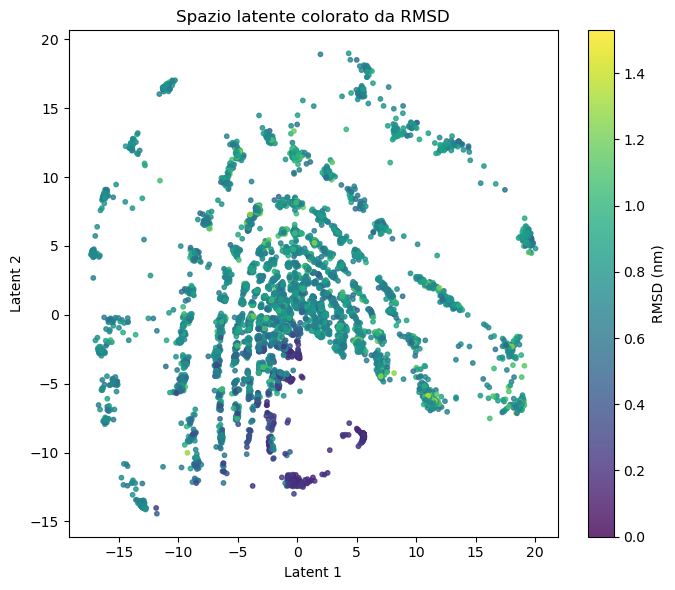

In [16]:
import numpy as np
import torch
import mdtraj as md
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from pkgs.model import DihedralTransformerAE
from pkgs.train import extract_latents
from pkgs.utils import DihedralDataset, angles_to_sincos, compute_aligned_phi_psi


# -----------------------------
# Config
# -----------------------------
trajectory = "/home/tedeschg/prj/cvformer/data/traj_skip100NoH.xtc"
topology = "/home/tedeschg/prj/cvformer/data/2JOF-0-proteinNoH.pdb"
weights_path = "/home/tedeschg/prj/cvformer/cvformer-test/test08/output/best_model_weights.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# -----------------------------
# 1) Carica traiettoria
# -----------------------------
traj = md.load(trajectory, top=topology)

# opzionale ma consigliato: allinea tutto al primo frame
traj.superpose(traj, 0)

# RMSD rispetto al primo frame
rmsd = md.rmsd(traj, traj, 0)   # shape: (n_frames,)


# -----------------------------
# 2) Prepara input come nel training
# -----------------------------
phi, psi, residue_ids, mask_np = compute_aligned_phi_psi(traj)
X = angles_to_sincos(phi, psi).astype(np.float32)

dataset = DihedralDataset(X, mask_np)
loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2)
mask_t = dataset.mask.to(device)

n_frames, n_tokens, _ = X.shape


# -----------------------------
# 3) Ricostruisci modello
#    usa gli stessi iperparametri del training
# -----------------------------
model = DihedralTransformerAE(
    n_tokens=n_tokens,
    d_model=64,
    nhead=4,
    num_encoder_layers=3,
    num_decoder_layers=3,
    dim_feedforward=256,
    dropout=0.15,
    latent_dim=2,
    memory_tokens=6,
).to(device)

model.load_state_dict(torch.load(weights_path, map_location=device))
model.eval()


# -----------------------------
# 4) Estrai latenti in memoria
# -----------------------------
latents = extract_latents(model, loader, device, mask_t)   # shape: (n_frames, latent_dim)

print("latents shape:", latents.shape)
print("rmsd shape:", rmsd.shape)


# -----------------------------
# 5) Plot spazio latente colorato da RMSD
# -----------------------------
if latents.shape[1] < 2:
    raise ValueError(f"Il latent_dim è {latents.shape[1]}, ma per uno scatter 2D servono almeno 2 dimensioni.")

plt.figure(figsize=(7, 6))
sc = plt.scatter(
    latents[:, 0],
    latents[:, 1],
    c=rmsd,
    s=10,
    alpha=0.8,
)
plt.xlabel("Latent 1")
plt.ylabel("Latent 2")
plt.title("Spazio latente colorato da RMSD")
cbar = plt.colorbar(sc)
cbar.set_label("RMSD (nm)")
plt.tight_layout()
plt.show()

In [ ]:
h = np.loadtxt('/home/tedeschg/prj/cvformer/cvformer-test/test06/test07/HILLS')


In [ ]:
plt.scatter(cv1,cv2, s=1, c='grey')
plt.scatter(h[:, 1], h[:, 2], s=1, c='green', )

plt.scatter(h[-1, 1], h[-1, 2], s=50, c='red')
plt.scatter(h[0, 1], h[0, 2], s=50, c='blue')


In [ ]:
import nglview as nv
import mdtraj as md


traj = md.load("/home/tedeschg/prj/cvformer/cvformer-test/test06/traj_skip100NoH.xtc", top="/home/tedeschg/prj/cvformer/cvformer-test/test06/2JOF-0-proteinNoH.pdb")

view = nv.show_mdtraj(traj)
view


In [ ]:
# === Encoding dei dati in data/, colorazione per RMSD, analisi aggiuntive ===

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import mdtraj as md

from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Config
# ------------------------------------------------------------
DATA_DIR = Path("../../data")
OUT_DIR = Path("output") if Path("output").exists() else Path(".")
LATENTS_PATH = OUT_DIR / "latents.npy"
WEIGHTS_PATH = OUT_DIR / "best_model_weights.pt"

TOP_EXTS = [".pdb", ".gro"]
TRAJ_EXTS = [".xtc", ".dcd", ".nc", ".trr"]

N_CLUSTERS = 5
RANDOM_STATE = 42
FIGSIZE = (7, 6)

# ------------------------------------------------------------
# Helpers per trovare topologia e traiettoria
# ------------------------------------------------------------
def find_first_existing(paths):
    for p in paths:
        if Path(p).exists():
            return Path(p)
    return None

def discover_topology_and_trajectory(data_dir: Path):
    tops = []
    trajs = []
    for ext in TOP_EXTS:
        tops.extend(sorted(data_dir.glob(f"**/*{ext}")))
    for ext in TRAJ_EXTS:
        trajs.extend(sorted(data_dir.glob(f"**/*{ext}")))

    if len(tops) == 0:
        raise FileNotFoundError(f"Nessuna topologia trovata in {data_dir} (attesi: {TOP_EXTS})")
    if len(trajs) == 0:
        raise FileNotFoundError(f"Nessuna traiettoria trovata in {data_dir} (attesi: {TRAJ_EXTS})")

    # prende i primi trovati; se vuoi rendilo pi﷿﷿﷿﷿﷿﷿ specifico
    return tops[0], trajs[0]

# ------------------------------------------------------------
# Caricamento traiettoria + RMSD backbone
# ------------------------------------------------------------
top_path, traj_path = discover_topology_and_trajectory(DATA_DIR)
print(f"Topologia:   {top_path}")
print(f"Traiettoria: {traj_path}")

traj = md.load(str(traj_path), top=str(top_path))
pdb = md.load(str(top_path))

# backbone atoms
bb_idx = traj.top.select("backbone")
rmsd = md.rmsd(traj, pdb, 0, atom_indices=bb_idx)

print(f"Frames traj: {traj.n_frames}")
print(f"RMSD shape:  {rmsd.shape}")

# ------------------------------------------------------------
# Encoding: prova a usare latents.npy, altrimenti model gi﷿﷿﷿﷿﷿﷿ in memoria
# ------------------------------------------------------------
def encode_with_model(traj, model):
    """
    ADATTA QUI se il tuo modello richiede un input specifico.
    Questa implementazione assume:
      - model gi﷿﷿﷿﷿﷿﷿ caricato nel notebook
      - input = coordinate cartesiane shape [n_frames, n_atoms, 3]
      - model(x) oppure model.encode(x) restituisce i latenti
    """
    import torch

    xyz = traj.xyz.astype(np.float32)  # [n_frames, n_atoms, 3]
    x = torch.from_numpy(xyz)

    device = next(model.parameters()).device if hasattr(model, "parameters") else torch.device("cpu")
    x = x.to(device)

    model.eval()
    with torch.no_grad():
        if hasattr(model, "encode"):
            z = model.encode(x)
        else:
            z = model(x)

    if hasattr(z, "detach"):
        z = z.detach().cpu().numpy()
    else:
        z = np.asarray(z)

    # appiattisce eventuali dimensioni non batch
    z = z.reshape(z.shape[0], -1)
    return z

latents = None

if LATENTS_PATH.exists():
    latents = np.load(LATENTS_PATH)
    print(f"Latenti caricati da: {LATENTS_PATH}  shape={latents.shape}")
else:
    if "model" in globals():
        print("latents.npy non trovato: provo a fare encoding con il modello gi﷿﷿﷿﷿﷿﷿ presente in memoria come `model`")
        latents = encode_with_model(traj, model)
        print(f"Latenti generati: shape={latents.shape}")
    else:
        raise RuntimeError(
            "Non trovo `output/latents.npy` e non esiste una variabile `model` nel notebook. "
            "Carica/istanzia prima il modello oppure salva i latenti."
        )

# ------------------------------------------------------------
# Allineamento numero frame
# ------------------------------------------------------------
n = min(len(rmsd), len(latents))
if len(rmsd) != len(latents):
    print(f"ATTENZIONE: taglio ai primi {n} elementi (rmsd={len(rmsd)}, latents={len(latents)})")

rmsd = rmsd[:n]
latents = latents[:n]

# ------------------------------------------------------------
# Standardizzazione + PCA 2D
# ------------------------------------------------------------
latents_scaled = StandardScaler().fit_transform(latents)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
z2 = pca.fit_transform(latents_scaled)

print("Explained variance ratio PCA:", pca.explained_variance_ratio_)

# ------------------------------------------------------------
# Plot embedding colorato per RMSD
# ------------------------------------------------------------
plt.figure(figsize=FIGSIZE)
sc = plt.scatter(z2[:, 0], z2[:, 1], c=rmsd, s=12, cmap="viridis")
plt.colorbar(sc, label="RMSD")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Embedding latente colorato per RMSD")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Analisi aggiuntiva 1: correlazione latenti vs RMSD
# ------------------------------------------------------------
corrs = []
for i in range(latents.shape[1]):
    c = np.corrcoef(latents[:, i], rmsd)[0, 1]
    corrs.append(c)

corrs = np.array(corrs)
topk = min(10, len(corrs))
best_idx = np.argsort(np.abs(corrs))[::-1][:topk]

print("\nTop dimensioni latenti per |corr(latent_dim, RMSD)|:")
for rank, idx in enumerate(best_idx, 1):
    print(f"{rank:2d}. dim {idx:3d}   corr = {corrs[idx]: .4f}")

plt.figure(figsize=(8, 3))
plt.bar(np.arange(len(corrs)), np.abs(corrs))
plt.xlabel("Latent dimension")
plt.ylabel("|corr con RMSD|")
plt.title("Importanza lineare delle dimensioni latenti rispetto a RMSD")
plt.tight_layout()
plt.show()

# scatter delle top 3 dimensioni pi﷿﷿﷿﷿﷿﷿ correlate
for idx in best_idx[:3]:
    plt.figure(figsize=(5, 4))
    plt.scatter(latents[:, idx], rmsd, s=10, alpha=0.7)
    plt.xlabel(f"Latent dim {idx}")
    plt.ylabel("RMSD")
    plt.title(f"Latent dim {idx} vs RMSD (corr={corrs[idx]:.3f})")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Analisi aggiuntiva 2: clustering nei latenti
# ------------------------------------------------------------
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
clusters = kmeans.fit_predict(latents_scaled)

plt.figure(figsize=FIGSIZE)
for c in range(N_CLUSTERS):
    mask = clusters == c
    plt.scatter(z2[mask, 0], z2[mask, 1], s=12, label=f"cluster {c}", alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clustering KMeans nello spazio latente")
plt.legend(markerscale=2, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("\nStatistiche RMSD per cluster:")
for c in range(N_CLUSTERS):
    vals = rmsd[clusters == c]
    print(
        f"cluster {c}: n={len(vals):4d} | "
        f"mean={vals.mean():.4f} | std={vals.std():.4f} | "
        f"min={vals.min():.4f} | max={vals.max():.4f}"
    )

# ------------------------------------------------------------
# Analisi aggiuntiva 3: frame estremi per RMSD
# ------------------------------------------------------------
lowest_idx = np.argsort(rmsd)[:5]
highest_idx = np.argsort(rmsd)[-5:][::-1]

print("\nFrame con RMSD pi﷿﷿﷿﷿﷿﷿ basso:")
for i in lowest_idx:
    print(f"frame {i:5d} | RMSD={rmsd[i]:.4f} | cluster={clusters[i]} | PCA=({z2[i,0]:.3f}, {z2[i,1]:.3f})")

print("\nFrame con RMSD pi﷿﷿﷿﷿﷿﷿ alto:")
for i in highest_idx:
    print(f"frame {i:5d} | RMSD={rmsd[i]:.4f} | cluster={clusters[i]} | PCA=({z2[i,0]:.3f}, {z2[i,1]:.3f})")

# ------------------------------------------------------------
# Analisi aggiuntiva 4: RMSD lungo la prima componente principale
# ------------------------------------------------------------
order = np.argsort(z2[:, 0])
plt.figure(figsize=(8, 4))
plt.plot(z2[order, 0], rmsd[order], ".", ms=4)
plt.xlabel("PC1")
plt.ylabel("RMSD")
plt.title("Andamento RMSD lungo PC1")
plt.tight_layout()
plt.show()

print("\nDone.")